# 8.4.1 约束乘子与最优性条件

## 学习目标与先修知识

推导等式及不等式的乘子条件，区分必要性、充分性与残差（residual）。

先修：8.1凸性（convexity）、8.2梯度（gradient）和线性方程；必要的乘子与对偶概念在本节引入。 [本篇学习次序](../README.md)。

## 具体问题

两种物质输入（input）强度需要尽量接近目标配置，但可用总量有限。最优点在边界上时梯度不为零，怎样识别它？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
H=np.diag([2.,4.]);b=np.array([4.,8.]);B=2.
unconstrained=np.linalg.solve(H,b);print('无约束解',unconstrained,'总量',sum(unconstrained),'预算',B)
z=np.linspace(0,B,1001);points=np.column_stack([z,B-z]);values=np.einsum('ni,ij,nj->n',points,H,points)/2-points@b
print('边界网格候选',points[values.argmin()])

无约束解 [2. 2.] 总量 4.0 预算 2.0
边界网格候选 [0.666 1.334]


## 模型假设

两个流量（flow）除以共同参考流量，因此总预算可以直接相加。目标二次正定（positive definite）。推导先看等式，再推广到gᵢ(x)≤0与仿射（affine）等式；明确必要条件所需的约束资格，以及凸问题中充分条件的范围。

## 数学解释与推导


等式 $x_1+x_2=B$ 的允许微小方向满足 $d_1+d_2=0$。
在规则约束的最优点，$\nabla f^Td=0$ 对所有切向方向成立，因此梯度必须沿约束法向。
引入拉格朗日乘子（Lagrange multiplier） $\nu$，令 $\mathcal L=f+\nu(x_1+x_2-B)$，驻点（stationary point）条件为
$Hx-b+\nu(1,1)^T=0$。联立等式：
$$\begin{pmatrix}H&a\\a^T&0\end{pmatrix}\begin{pmatrix}x\\\nu\end{pmatrix}=\begin{pmatrix}b\\B\end{pmatrix},\quad a=(1,1)^T.$$
乘子不是额外观测（observation）参数（parameter），而是目标对约束的权衡量；等式乘子符号自由。

对不等式 $g_i\le0$ 采用 $\mathcal L=f+\sum_i\lambda_i g_i+\nu^Th$，非负乘子使可行点上 $\mathcal L\le f$。
Karush–Kuhn–Tucker条件（KKT conditions）包含四项：原始可行 $g\le0,h=0$；对偶可行 $\lambda\ge0$；驻点 $\nabla_x\mathcal L=0$；互补松弛（complementary slackness） $\lambda_i g_i=0$。
未活跃约束 $g_i<0$ 的乘子必为零；活跃约束可有零乘子。

在凸可微目标、凸可微不等式和仿射等式下，满足KKT的点是全局最小：
驻点使凸函数 $\mathcal L(\cdot,\lambda,\nu)$ 在该点最小；互补使其值等于 $f(x^*)$；任意可行z满足
$$f(x^*)=\mathcal L(x^*,\lambda,\nu)\le\mathcal L(z,\lambda,\nu)\le f(z).$$
充分性本身不另需约束资格；若要断言“每个最优点都有这些乘子”，则要适当资格。
例如凸问题中存在满足仿射等式且使全部不等式严格成立的点，是常用的Slater充分资格（这里限目标与约束在全空间有限可微）。
反例：最小化x，约束 $x^2\le0$，唯一可行点0最优，却无法满足 $1+\lambda\cdot0=0$。

对于 $Ax\le c$ 的二次问题，分别报告最大正违反量、最大负乘子、$\|Hx-b+A^T\lambda\|_\infty$ 和最大 $|\lambda_i(Ax-c)_i|$。
这些残差分别衡量约束和最优性条件的偏离，判断大小时要结合变量尺度与所需精度。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def kkt_residuals(matrix, linear, constraints, bounds, point, multipliers, tolerance):
    _, gradient, _ = quadratic(matrix, linear, point)
    violation = [sum(a*x for a, x in zip(row, point))-c for row, c in zip(constraints, bounds)]
    stationarity = [g+sum(row[j]*v for row, v in zip(constraints, multipliers))
                    for j, g in enumerate(gradient)]
    primal = max([0.]+violation)
    dual = max([0.]+[-value for value in multipliers])
    stationary = max([0.]+[abs(x) for x in stationarity])
    complementary = max([0.]+[abs(v*r) for v, r in zip(multipliers, violation)])
    residuals = [primal, dual, stationary, complementary]
    return residuals, 'verified' if max(residuals)<=tolerance else 'rejected'

## 对照实验

| 候选 | 原始 | 对偶 | 驻点 | 互补 | 结论 |
| --- | --- | --- | --- | --- | --- |
| 最优证书 | 0 | 0 | 4.44089e-16 | 0 | verified |
| 可行但不最优 | 0 | 0 | 4 | 0 | rejected |
| 不可行候选 | 2 | 0 | 0 | 0 | rejected |

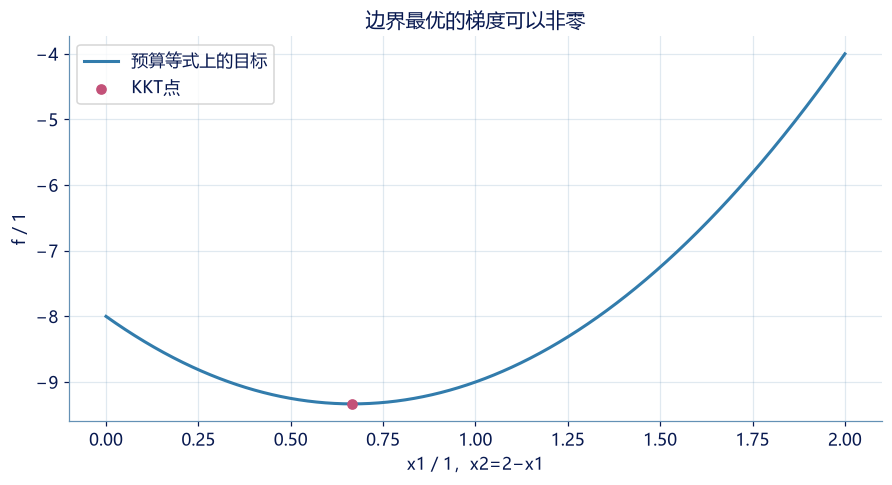

In [4]:
A=np.array([[1.,1.],[-1.,0.],[0.,-1.]]);c=np.array([B,0.,0.]);opt=np.array([2/3,4/3]);multipliers=[8/3,0.,0.]
rows=[]
for name,point,lam in [('最优证书',opt,multipliers),('可行但不最优',[1.,1.],[0.,0.,0.]),('不可行候选',[2.,2.],[0.,0.,0.])]:
    residual,status=kkt_residuals(H.tolist(),b.tolist(),A.tolist(),c.tolist(),list(point),lam,1e-8)
    rows.append([name,*residual,status])
display(Markdown(show_table(['候选','原始','对偶','驻点','互补','结论'],rows)))
fig,ax=plt.subplots(figsize=(8,4.3));ax.plot(z,values,color=BLUE,label='预算等式上的目标')
ax.scatter([opt[0]],[quadratic(H,b,opt)[0]],color=PINK,zorder=3,label='KKT点')
ax.set(xlabel='x1 / 1，x2=2−x1',ylabel='f / 1',title='边界最优的梯度可以非零');ax.legend();plt.show()

### 独立核验与边界

In [5]:
np.testing.assert_allclose(H@opt-b+A.T@multipliers,0,atol=1e-12)
assert kkt_residuals(H,b,A,c,opt,multipliers,1e-8)[1]=='verified'
candidate=np.array([1.,1.]);difference=quadratic(H,b,candidate)[0]-quadratic(H,b,opt)[0]
assert difference>0
q=lambda lam: -.5*(b-A.T@lam)@np.linalg.solve(H,b-A.T@lam)-c@lam
assert abs(q(np.array(multipliers))-quadratic(H,b,opt)[0])<1e-12
print('驻点方程与独立对偶下界一致；可行候选不自动最优。')

驻点方程与独立对偶下界一致；可行候选不自动最优。


## 结果解释

表格拆开了“在约束内”和“已最优”。最优解的目标等于对偶下界，提供独立于求解结论标签文字的证据。对非凸目标，驻点方程一般只提供候选，不能照搬这里的凸充分性。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：核对四类最优性残差

对严格凸二次目标与线性不等式，核对给定候选点及乘子，不运行优化器。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    constraints: list[list[float]],
    bounds: list[float],
    point: list[float],
    multipliers: list[float],
    tolerance: float,
) -> tuple[list[float], str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `constraints` | `list[list[float]]` | 不等式行A，规定Ax≤c。 | 无量纲 |
| `bounds` | `list[float]` | 右端c，与约束行同序。 | 无量纲 |
| `point` | `list[float]` | 当前优化变量 x。 | 无量纲 |
| `multipliers` | `list[float]` | 候选不等式乘子λ，与约束行同序。 | 无量纲 |
| `tolerance` | `float` | 四个残差（residual）统一的绝对阈值。 | 无量纲 |

**返回值**

按以下顺序返回元组：(residuals, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `residuals` | `list[float]` | 依次为原始可行、对偶可行、驻点（stationary point）和互补残差。 | 无量纲 |
| `status` | `str` | 全部残差≤tolerance为verified，否则rejected。 | 不适用 |

**计算规则**

记r=Ax−c，s=Hx−b+Aᵀλ。返回[max(0,max r), max(0,max −λ), max|s|, max|λᵢrᵢ|]；空约束的相应最大值取0。rejected仅说明候选不合格，不能判定问题不可行。

**约束与边界**

- 维数1或2，H正定（positive definite）；0—5行线性约束；全部量已无量纲（dimensionless）化，tolerance>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 2.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [4.0, 4.0] | 无量纲 |
| constraints | 不等式行A，规定Ax≤c。 | [[1.0, 1.0], [-1.0, 0.0], [0.0, -1.0]] | 无量纲 |
| bounds | 右端c，与约束行同序。 | [2.0, 0.0, 0.0] | 无量纲 |
| point | 当前优化变量 x。 | [1.0, 1.0] | 无量纲 |
| multipliers | 候选不等式乘子λ，与约束行同序。 | [2.0, 0.0, 0.0] | 无量纲 |
| tolerance | 四个残差（residual）统一的绝对阈值。 | 1e-08 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 2.0]]
linear = [4.0, 4.0]
constraints = [[1.0, 1.0], [-1.0, 0.0], [0.0, -1.0]]
bounds = [2.0, 0.0, 0.0]
point = [1.0, 1.0]
multipliers = [2.0, 0.0, 0.0]
tolerance = 1e-08

result = solve(matrix, linear, constraints, bounds, point, multipliers, tolerance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| residuals | 依次为原始可行、对偶可行、驻点（stationary point）和互补残差。 | [0.0, 0.0, 0.0, 0.0] | 无量纲 |
| status | 全部残差≤tolerance为verified，否则rejected。 | verified | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 0.0, 0.0, 0.0], 'verified')
```

**样例解释**

点[1,1]恰好用完预算2，乘子2抵消梯度（gradient）[−2,−2]，四个残差为0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：核对四类最优性残差](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-kkt)

### 第 2 题 · 多项选择题：条件何时必要或充分

对可微凸目标、可微凸不等式和仿射（affine）等式，以下哪些表述正确？

- **A.** 满足KKT的原始/对偶点可证明全局最优。
- **B.** 任意非凸问题中KKT都是全局充分条件。
- **C.** 适当约束资格用于保证最优点存在相应乘子。
- **D.** 只检查原始可行性就证明最优。

[作答：条件何时必要或充分](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-necessity-sufficiency)

### 第 3 题 · 多项选择题：退化约束为什么重要

最小化f(x)=x，约束x²≤0，唯一可行点x=0。关于KKT有哪些正确判断？

- **A.** 0必不是最优，因为找不到乘子。
- **B.** 0是唯一可行点，当然最优。
- **C.** 在0，驻点（stationary point）条件为1+λ·0=0，不可能满足。
- **D.** 这个例子说明必要性要检查约束资格。

[作答：退化约束为什么重要](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-constraint-qualification)

### 第 4 题 · 多项选择题：乘子的符号从哪来

目标f，约束g(x)≤0，采用L=f+λg。哪些说法正确？

- **A.** 不等式乘子应非负。
- **B.** 互补条件为λg(x)=0。
- **C.** 未活跃约束g(x)<0时，KKT要求λ=0。
- **D.** 等式约束的乘子也必须非负。

[作答：乘子的符号从哪来](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-multiplier-sign)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第5章：拉格朗日对偶、Slater条件与KKT。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-04-约束与最优性条件/explore/) · [本篇目录](../README.md)